In [ ]:
!pip install snowflake-connector-python
import snowflake.connector
import pandas as pd

In [ ]:

conn=snowflake.connector.connect(
              user='Anshif',
              password='Anshking78607860#',
              account='BQMWLMR-KP02548',
              database='GENDER',
              schema='PUBLIC',
               warehouse='COMPUTE_WH'
)

query='SELECT * FROM  "GENDER"'
df=pd.read_sql(query,conn)
conn.close()

df.head(10)

/tmp/ipykernel_2039/3545802082.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,LONG_HAIR,FOREHEAD_WIDTH_CM,FOREHEAD_HEIGHT_CM,NOSE_WIDE,NOSE_LONG,LIPS_THIN,DISTANCE_NOSE_TO_LIP_LONG,GENDER
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
5,1,13.0,6.8,1,1,1,1,Male
6,1,15.3,6.2,1,1,1,0,Male
7,0,13.0,5.2,0,0,0,0,Female
8,1,11.9,5.4,1,0,1,1,Female
9,1,12.1,5.4,0,0,0,0,Female


In [ ]:
df.isna().sum()

,0
LONG_HAIR,0
FOREHEAD_WIDTH_CM,0
FOREHEAD_HEIGHT_CM,0
NOSE_WIDE,0
NOSE_LONG,0
LIPS_THIN,0
DISTANCE_NOSE_TO_LIP_LONG,0
GENDER,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   LONG_HAIR                  5001 non-null   int64  
 1   FOREHEAD_WIDTH_CM          5001 non-null   float64
 2   FOREHEAD_HEIGHT_CM         5001 non-null   float64
 3   NOSE_WIDE                  5001 non-null   int64  
 4   NOSE_LONG                  5001 non-null   int64  
 5   LIPS_THIN                  5001 non-null   int64  
 6   DISTANCE_NOSE_TO_LIP_LONG  5001 non-null   int64  
 7   GENDER                     5001 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 312.7 KB


In [ ]:
df.describe()

,LONG_HAIR,FOREHEAD_WIDTH_CM,FOREHEAD_HEIGHT_CM,NOSE_WIDE,NOSE_LONG,LIPS_THIN,DISTANCE_NOSE_TO_LIP_LONG,GENDER
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.00000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900,0.49990
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049,0.50005
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000,0.00000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000,1.00000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['GENDER']=le.fit_transform(df[['GENDER']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


<Axes: ylabel='FOREHEAD_WIDTH_CM'>

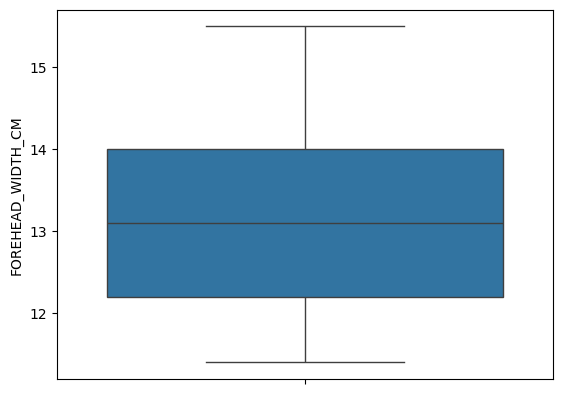

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(df['FOREHEAD_WIDTH_CM'])

<Axes: ylabel='FOREHEAD_HEIGHT_CM'>

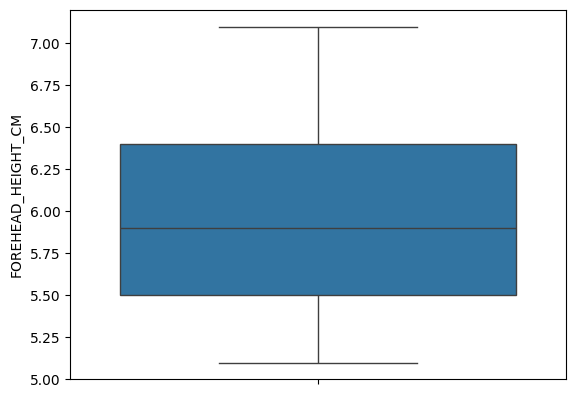

In [ ]:
sns.boxplot(df['FOREHEAD_HEIGHT_CM'])

<Axes: >

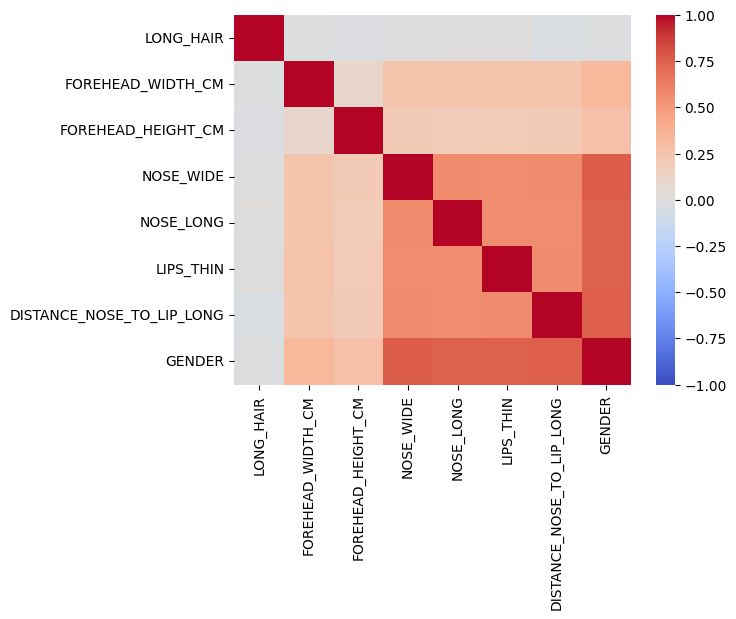

In [ ]:
corr=df.corr()
sns.heatmap(corr,cmap='coolwarm',vmax=1,vmin=-1)

In [ ]:
X=df[['LONG_HAIR','NOSE_WIDE','NOSE_LONG','LIPS_THIN','DISTANCE_NOSE_TO_LIP_LONG']]
y=df['GENDER']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(criterion='entropy',random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
y_pred=model.predict(X_test)
print(y_pred)

[1 1 0 ... 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy Score: 0.9560439560439561
Confusion Matrix:
 [[467  16]
 [ 28 490]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       483
           1       0.97      0.95      0.96       518

    accuracy                           0.96      1001
   macro avg       0.96      0.96      0.96      1001
weighted avg       0.96      0.96      0.96      1001



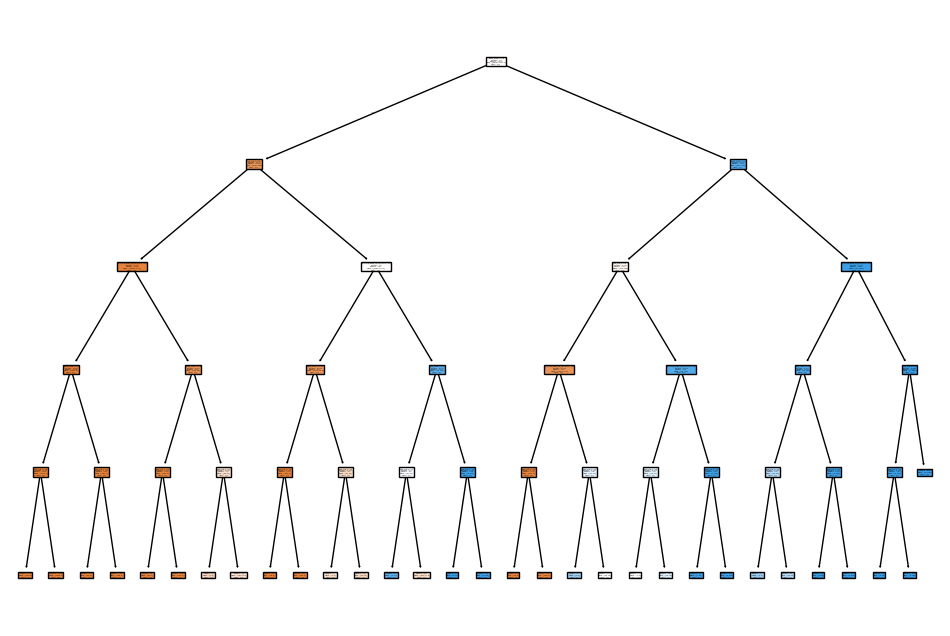

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns, class_names=True, filled=True)

plt.show()